# H3N2 Gradient × Input：归因与元信息整合

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

def clean(value):
    return '' if pd.isna(value) else str(value).strip()

def build_records(whole_csv):
    """Create attribution-aligned H3N2 HA1 records and their metadata."""
    whole = pd.read_csv(whole_csv)
    type_column = 'serumType' if 'serumType' in whole.columns else 'Type'

    processed = whole[whole[type_column].map(clean).str.casefold().eq('h3n2')].copy()
    processed = processed[
        processed['seq_a'].map(clean).str.len().eq(329)
        & processed['seq_c'].map(clean).str.len().eq(329)
    ].copy()
    processed = processed.drop_duplicates(DEDUP_COLUMNS, keep='first').reset_index(drop=True)
    processed.insert(0, 'sample_index', np.arange(len(processed), dtype=np.int64))
    return processed, processed[METADATA_COLUMNS].copy()

def load_attributions(attribution_csv, processed):
    """Load attribution rows and verify their stable sample order."""
    attribution = pd.read_csv(attribution_csv)
    if not attribution['sample_index'].equals(processed['sample_index']):
        raise ValueError('Attribution rows do not match the processed sample order.')
    return attribution

def build_analysis_table(attribution, record_dates):
    """Join per-sample attributions to dates and other analysis metadata."""
    attribution_with_dates = attribution.merge(
        record_dates,
        on=['sample_index', 'seq_id_a', 'seq_id_c', 'serumName', 'virusName'],
        how='left',
        validate='one_to_one',
    )
    return attribution_with_dates

def summarize_query_sites(table):
    """Rank HA1 query positions by mean absolute attribution in `table`."""
    token_columns = table.filter(regex=r'^combined_token_\d+$').columns


    summary = table[token_columns].abs().mean().rename("mean_attribution").reset_index()
    summary = summary.rename(columns={"index": "token"})
    summary["positive_fraction"] = table[token_columns].gt(0).mean().to_numpy()
    summary['token_index'] = summary['token'].str.extract(r'(\d+)$').astype(int)
    return (
        summary.query("1 <= token_index <= 329 and mean_attribution > 0")
        .rename(columns={"token_index": "aa_position"})
        .sort_values("mean_attribution", ascending=False)
        .reset_index(drop=True)
    )

def add_flu_season(table):
    result = table.copy()
    date = pd.to_datetime(result["virusDate"], errors="coerce", format="mixed")

    year = (date.dt.year - (date.dt.month <= 4)).astype("Int64").astype(str)
    result["flu_season"] = year + np.where(date.dt.month.between(5, 9), "SH", "NH")

    return result

def build_season_top(table, TOP_K, years):
    """Rank the 15 highest mean-absolute query sites in every flu season."""
    selected_seasons = [
        f"{year}{hemisphere}"
        for year in range(years[0], years[1] + 1)
        for hemisphere in ("SH", "NH")
    ]
    rows = []
    table = table[table['flu_season'].isin(selected_seasons)]
    for season, season_table in table.dropna(subset=["flu_season"]).groupby("flu_season"):
        top15 = summarize_query_sites(season_table).head(TOP_K).copy()
        top15.insert(0, "flu_season", season)
        top15.insert(1, "rank", np.arange(1, TOP_K + 1))
        top15.insert(2, "sample_count", len(season_table))
        rows.append(top15)
    return pd.concat(rows, ignore_index=True)


In [2]:
ROOT_PATH = '/home/chenyh/workspace/fluProfiler/'
WHOLE_CSV = ROOT_PATH + 'data/dataset/H1H3_HA1_v1.0/splited/20260717_164256/whole/whole.csv'
ATTRIBUTION_CSV = ROOT_PATH + 'results/H1H3_HA1_v1.0/20260717_164256/' + \
    'SerumGate-Minus-latent8/titer/seed_0/subtype/H3N2/gradient_x_input/attribution_by_sample.csv'

DEDUP_COLUMNS = ['seq_a', 'seq_c', 'serumPassCat', 'virusPassCat']
MERGE_KEYS = ['sample_index', 'seq_id_a', 'seq_id_c', 'serumName', 'virusName']
METADATA_COLUMNS = [*MERGE_KEYS, 'serumDate', 'virusDate']

In [3]:
processed, record_dates = build_records(WHOLE_CSV)
attribution = load_attributions(ATTRIBUTION_CSV, processed)
attribution_with_dates = build_analysis_table(attribution, record_dates)

print(f'Integrated {len(attribution_with_dates):,} attribution samples.')

Integrated 24,740 attribution samples.


# 不分流感季看非保守位点总体梯度

In [4]:
sequences = (
    pd.concat(
        [attribution_with_dates["seq_a"], attribution_with_dates["seq_c"]],
        ignore_index=True,
    )
    .dropna()
    .astype(str)
)

sequence_matrix = np.array([list(sequence) for sequence in sequences])

site_conservation = pd.DataFrame({
    "aa_position": np.arange(1, sequence_matrix.shape[1] + 1),
    "n_unique_aa": [
        len(np.unique(sequence_matrix[:, i]))
        for i in range(sequence_matrix.shape[1])
    ],
})

site_conservation["is_conserved"] = site_conservation["n_unique_aa"].eq(1)

conserved_sites = site_conservation.query("is_conserved")["aa_position"].tolist()

display(site_conservation)
print(f"完全保守位点数: {len(conserved_sites)}")
print("完全保守位点:", conserved_sites)

,aa_position,n_unique_aa,is_conserved
0,1,3,False
1,2,5,False
2,3,8,False
3,4,6,False
4,5,5,False
...,...,...,...
324,325,4,False
325,326,4,False
326,327,4,False
327,328,7,False


完全保守位点数: 66
完全保守位点: [14, 16, 26, 41, 52, 64, 68, 71, 72, 73, 74, 76, 84, 89, 90, 97, 98, 99, 100, 108, 110, 113, 116, 120, 125, 127, 132, 134, 136, 139, 147, 148, 151, 152, 153, 154, 170, 176, 178, 180, 181, 185, 200, 206, 224, 234, 235, 249, 250, 253, 254, 256, 257, 277, 281, 283, 286, 295, 303, 305, 306, 314, 317, 319, 321, 322]


In [5]:
positions = np.arange(1, 330)

ref_columns = [f"reference_token_{i}" for i in positions]
query_columns = [f"query_token_{i}" for i in positions]
combined_columns = [f"combined_token_{i}" for i in positions]
ref_info = attribution_with_dates.drop(columns=query_columns)
query_info = attribution_with_dates.drop(columns=ref_columns)
combined_info = attribution_with_dates.drop(columns=(ref_columns + query_columns))

combined_tokens = pd.DataFrame(
    attribution_with_dates[ref_columns].to_numpy(dtype=float)
    + attribution_with_dates[query_columns].to_numpy(dtype=float),
    index=attribution_with_dates.index,
    columns=combined_columns,
)

# 若希望同时保留元信息、ref、query、combined：
combined_info = pd.concat(
    [
        attribution_with_dates,
        combined_tokens,
    ],
    axis=1,
)
combined_info = combined_info.drop(columns=[f"combined_token_{i}" for i in conserved_sites])

In [6]:
select_cols = [f"combined_token_{i}" for i in positions if i not in conserved_sites]
dd = {}
for col in select_cols:
    dd[int(col.split("_")[-1])] = combined_info[col].abs().mean(0).item()

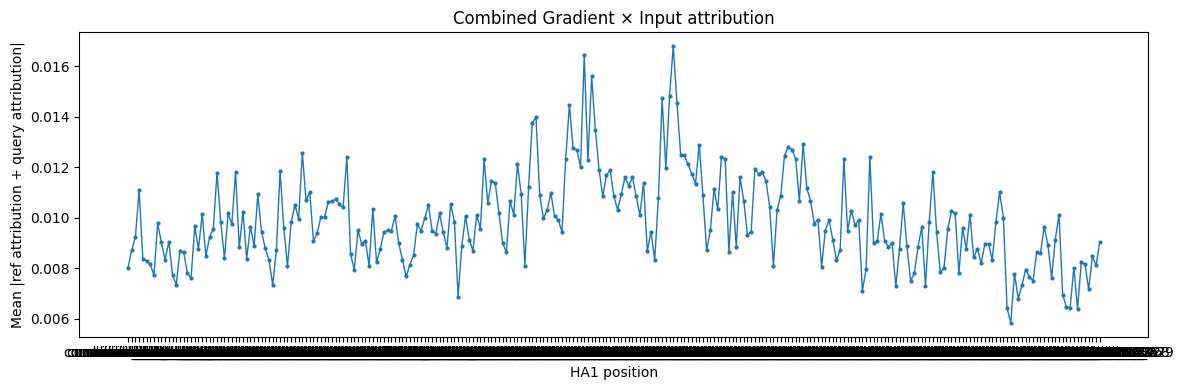

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(select_cols, dd.values(), marker="o", markersize=2, linewidth=1)
plt.xlabel("HA1 position")
plt.ylabel("Mean |ref attribution + query attribution|")
plt.title("Combined Gradient × Input attribution")
plt.tight_layout()
plt.show()

In [8]:
top25_keys = sorted(dd, key=dd.get, reverse=True)[:30]

top25_values = [dd[key] for key in top25_keys]

list(zip(top25_keys, top25_values))

[(190, 0.016797529958528488),
 (160, 0.01643373291894145),
 (162, 0.01562633673320324),
 (189, 0.014824615732853132),
 (187, 0.014725081474137605),
 (191, 0.01455932403901578),
 (156, 0.014474383664532114),
 (141, 0.013971011182285841),
 (140, 0.013750714752860816),
 (163, 0.013478116223731216),
 (228, 0.01293439701342633),
 (197, 0.012896596992890084),
 (223, 0.012782828356390668),
 (157, 0.012747186268043676),
 (225, 0.012701820883423429),
 (158, 0.012693960220198275),
 (53, 0.012574900351661969),
 (192, 0.01248900050738834),
 (193, 0.012467851388860848),
 (222, 0.012464095136308567),
 (66, 0.0124212385546356),
 (204, 0.012416028210763336),
 (248, 0.01241227534801565),
 (241, 0.01234431965450693),
 (226, 0.012339238064398041),
 (155, 0.01232631128599468),
 (205, 0.012324966310733461),
 (121, 0.012316821452070642),
 (161, 0.012266946764588367),
 (133, 0.012139757032052095)]

In [9]:
import pandas as pd

annotation_path = "/home/chenyh/workspace/fluProfiler/paper/data/ABCDE.csv"
annotations = pd.read_csv(annotation_path)
annotations = annotations.rename(columns={
            "Amino acid residues of HA1": "aa_position",
            "Antigenic epitope": "epitope",
            "Receptor binding site": "RBS",
            "glycosylation site": "glycosylation",
        })

top25_alignment = (
    pd.DataFrame({
        "aa_position": top25_keys,
        "combined_mean_abs_attribution": top25_values,
    })
    .merge(
        annotations,
        on="aa_position",
        how="left",
    )
    # .sort_values("combined_mean_abs_attribution", ascending=False)
    .sort_values(
    by=["epitope", "aa_position"],
    ascending=[True, True])
    .reset_index(drop=True)
)

display(top25_alignment)

,aa_position,combined_mean_abs_attribution,epitope,RBS,glycosylation
0,133,0.012140,A,NaN,√
1,140,0.013751,A,NaN,NaN
2,155,0.012326,B,√,NaN
3,156,0.014474,B,NaN,NaN
4,157,0.012747,B,NaN,NaN
5,158,0.012694,B,NaN,NaN
6,160,0.016434,B,NaN,NaN
7,163,0.013478,B,NaN,NaN
8,187,0.014725,B,NaN,NaN
9,189,0.014825,B,NaN,NaN


# 按照季节分别分组聚合，看位点贡献

In [10]:
dates = pd.to_datetime(combined_info["virusDate"], errors="coerce", format="mixed")

print(f"总记录数：{len(dates):,}")
print(f"可正常解析：{dates.notna().sum():,}")
print(f"缺失或无法解析：{dates.isna().sum():,}")

print("\n日期范围：")
print(f"最早：{dates.min()}")
print(f"最晚：{dates.max()}")

print("\n无法解析的原始值及频数：")
display(
    combined_info.loc[dates.isna(), "virusDate"]
    .fillna("<missing>")
    .value_counts()
)

总记录数：24,740
可正常解析：24,436
缺失或无法解析：304

日期范围：
最早：2006-07-11 00:00:00
最晚：2025-06-17 00:00:00

无法解析的原始值及频数：


virusDate
<missing>    304
Name: count, dtype: int64

In [23]:
## 获取按照季节聚合后非保守位点的贡献
top_k = 5

before_n = len(combined_info)
combined_info = combined_info.dropna(subset=["virusDate"]).copy()
removed_n = before_n - len(combined_info)
print(f"已清除 virusDate 缺失的样本：{removed_n:,} 条")
print(f"清洗后剩余样本：{len(combined_info):,} 条")

attribution_with_seasons = add_flu_season(combined_info)
token_columns = attribution_with_seasons.filter(regex=r'^combined_token_\d+$').columns
attribution_with_seasons[token_columns] = attribution_with_seasons[token_columns].abs()
agg_dict = {col: 'first' for col in attribution_with_seasons.columns}
agg_dict.update({col: 'mean' for col in token_columns})
# agg_dict.pop('flu_season', None)
attribution_with_seasons = attribution_with_seasons.groupby('flu_season').agg(agg_dict).reset_index(drop=True)

已清除 virusDate 缺失的样本：0 条
清洗后剩余样本：24,436 条


In [24]:
## 按照季节对所有位点的贡献进行归一化
token_cols = [c for c in attribution_with_seasons.columns if c.startswith('combined_token_')]
row_sums = attribution_with_seasons[token_cols].sum(axis=1)
attribution_with_seasons[token_cols] = (
    attribution_with_seasons[token_cols]
    .div(row_sums.replace(0, np.nan), axis=0)
    .fillna(0)
)

In [27]:
# 得到每个季节top5位点的并集
season_top_site_union = build_season_top(attribution_with_seasons, 5, (2015,2026))
season_top_site_union_aligned = (
    season_top_site_union
    .merge(
        annotations,
        on="aa_position",
        how="left",
    )[["aa_position", "epitope", "RBS", "glycosylation"]].drop_duplicates(
    )
    .reset_index(drop=True)
)

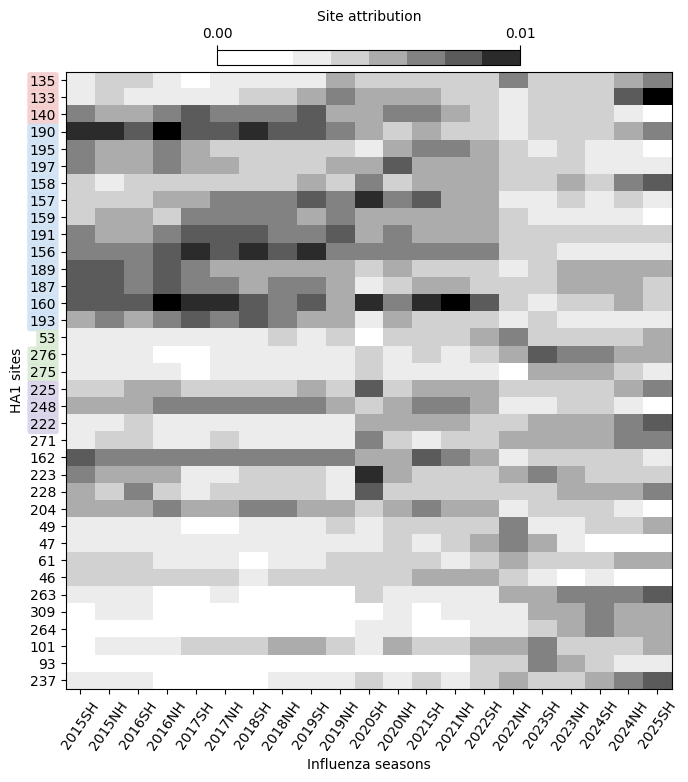

In [28]:
from matplotlib.colors import BoundaryNorm

HEATMAP_SEASONS = [
    f"{year}{hemisphere}"
    for year in range(2015, 2026)
    for hemisphere in ("SH", "NH")
]
HEATMAP_SEASONS.remove('2025NH')
token_cols = [c for c in attribution_with_seasons.columns if c.startswith('combined_token_')]
keep_cols = ['flu_season'] + token_cols
heatmap_positions = season_top_site_union_aligned \
    .sort_values('epitope')['aa_position']

df_origin = attribution_with_seasons.loc[attribution_with_seasons['flu_season'].isin(HEATMAP_SEASONS), keep_cols]
df_long = (
    df_origin
    .melt(
        id_vars=[c for c in df_origin.columns if c not in token_cols],
        value_vars=token_cols,
        var_name='token_position',
        value_name='combined_token',
    )
    .assign(
        token_position=lambda x: x['token_position'].str.extract(r'(\d+)$').astype(int)
    )
    # .sort_values('epitope')
    .reset_index(drop=True)
)

heatmap_values = (
    df_long.pivot(
        index="token_position",
        columns="flu_season",
        values="combined_token",
    )
    .reindex(index=heatmap_positions, columns=HEATMAP_SEASONS)
)
attribution_with_seasons

# cmap = plt.get_cmap("Greys").copy()
# cmap.set_bad("white")
n_bins = 8  # 分成 5 个灰度区间

values = heatmap_values.to_numpy()
bounds = np.linspace(0, 0.01, n_bins + 1)

cmap = plt.get_cmap("Greys", n_bins).copy()
cmap.set_bad("white")
norm = BoundaryNorm(bounds, cmap.N, clip=True)
fig_height = max(6, len(heatmap_values) * 0.22)
fig, ax = plt.subplots(figsize=(7, fig_height))
image = ax.imshow(
    np.ma.masked_invalid(heatmap_values.to_numpy()),
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
)
ax.set_xticks(np.arange(len(HEATMAP_SEASONS)))
ax.set_xticklabels(HEATMAP_SEASONS, rotation=55, ha="center")
ax.set_yticks(np.arange(len(heatmap_values)))
ax.set_yticklabels(heatmap_values.index.astype(str))

epitope_backgrounds = {
    "A": "#F4CCCC",  # 浅红
    "B": "#CFE2F3",  # 浅蓝
    "C": "#D9EAD3",  # 浅绿
    "D": "#D9D2E9",  # 浅紫
    "E": "#FCE5CD",  # 浅橙
}

position_to_epitope = (
    season_top_site_union_aligned
    .drop_duplicates("aa_position")
    .set_index("aa_position")["epitope"]
)

for label, position in zip(ax.get_yticklabels(), heatmap_values.index):
    epitope = position_to_epitope.get(position)

    if epitope in epitope_backgrounds:
        label.set_bbox({
            "facecolor": epitope_backgrounds[epitope],
            "edgecolor": "none",
            "alpha": 0.9,
            "boxstyle": "round,pad=0.18",
        })

ax.set_xlabel("Influenza seasons")
ax.set_ylabel("HA1 sites")

colorbar = fig.colorbar(
    image,
    ax=ax,
    location="top",
    orientation="horizontal",
    pad=0.01,
    fraction=0.035,  # 色条高度
    shrink=0.5,      # 色条长度
    boundaries=bounds,
    ticks=[bounds[0], bounds[-1]],
)
colorbar.set_label("Site attribution")
plt.tight_layout()
plt.show()
plt.close(fig)


In [152]:
import re

token_cols = [c for c in attribution_with_seasons.columns if c.startswith('combined_token_')]
keep_cols = ['flu_season'] + token_cols
dd = attribution_with_seasons[keep_cols]


df_long = (
    dd
    .melt(
        id_vars=[c for c in dd.columns if c not in token_cols],
        value_vars=token_cols,
        var_name='token_position',
        value_name='combined_token',
    )
    .assign(
        token_position=lambda x: x['token_position'].str.extract(r'(\d+)$').astype(int)
    )
    .sort_values('token_position')
    .reset_index(drop=True)
)

In [153]:
df_long

,flu_season,token_position,combined_token
0,2006NH,1,0.007298
1,2006SH,1,0.011858
2,2008NH,1,0.001500
3,2007NH,1,0.018262
4,2008SH,1,0.020240
...,...,...,...
10252,2008NH,329,0.017014
10253,2022NH,329,0.005930
10254,2022SH,329,0.008463
10255,2008SH,329,0.012736


In [115]:
heatmap_top15

,flu_season,rank,sample_count,token,mean_attribution,positive_fraction,aa_position,season_rank,epitope,RBS,glycosylation
0,2015NH,1,600,combined_token_162,0.027390,0.910000,162,2015NH:1,NaN,NaN,NaN
1,2015NH,2,600,combined_token_160,0.026746,0.890000,160,2015NH:2,B,NaN,NaN
2,2015NH,3,600,combined_token_190,0.025746,0.898333,190,2015NH:3,B,√,NaN
3,2015NH,4,600,combined_token_187,0.023732,0.881667,187,2015NH:4,B,NaN,NaN
4,2015NH,5,600,combined_token_163,0.022608,0.926667,163,2015NH:5,B,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
100,2025NH,1,1000,combined_token_133,0.036793,0.899000,133,2025NH:1,A,NaN,√
101,2025NH,2,1000,combined_token_158,0.027463,0.903000,158,2025NH:2,B,NaN,NaN
102,2025NH,3,1000,combined_token_222,0.025682,0.936000,222,2025NH:3,D,NaN,NaN
103,2025NH,4,1000,combined_token_220,0.025387,0.948000,220,2025NH:4,D,NaN,NaN


In [105]:
heatmap_top15.groupby("aa_position").agg(season_count=("flu_season", "nunique"), best_rank=("rank", "min"),epitope=("epitope", "min"))

,season_count,best_rank,epitope
aa_position,,,
21,5,2,NaN
25,4,4,Un
33,1,3,Un
46,8,1,NaN
47,2,2,NaN
49,2,3,NaN
53,5,1,C
54,4,1,C
61,1,5,NaN
